In [1]:
import numpy as np
import matplotlib.pyplot as plt
import croak

g = croak.Grid(128, dt=0.3e-15)
ew = croak.gaussian_pulse(g, 3.0e-15, phases=[6e-30, 30e-45])   # GDD + TOD
delays = np.linspace(-24e-15, 24e-15, 90)
trace = croak.maketrace(g.omega, delays, ew, "pg")              # PG-FROG

In [2]:
guess = croak.gaussian_pulse(g, 2.0e-15)     # a deliberately rough start

results = {}
for algo in ("copra", "lbfgs", "lm"):
    results[algo] = croak.retrieve(trace, g.omega, delays, "pg",
                                  algorithm=algo, guess=guess, maxiters=200,
                                  rng=np.random.default_rng(0))

for algo, res in results.items():
    print(f"{algo:6s}  R = {res.error:.2e}  ({len(res.errors)} evaluations)")

retrieving:   0%|          | 0/200 [00:00<?, ?it/s]

retrieval complete — copra / pg
  final error R    : 0.0000%
  retrieved FWHM   : 4.76 fs
  transform limit  : 3.00 fs
  iterations       : 200
  time taken       : 1.57 s


retrieving:   0%|          | 0/200 [00:00<?, ?it/s]

retrieval complete — lbfgs / pg
  final error R    : 0.0080%
  retrieved FWHM   : 4.78 fs
  transform limit  : 2.62 fs
  iterations       : 200
  time taken       : 1.35 s


retrieving:   0%|          | 0/200 [00:00<?, ?it/s]

retrieval complete — lm / pg
  final error R    : 0.0003%
  retrieved FWHM   : 4.76 fs
  transform limit  : 2.97 fs
  iterations       : 19
  time taken       : 1.93 s
copra   R = 8.98e-17  (200 evaluations)
lbfgs   R = 8.01e-05  (200 evaluations)
lm      R = 3.13e-06  (19 evaluations)


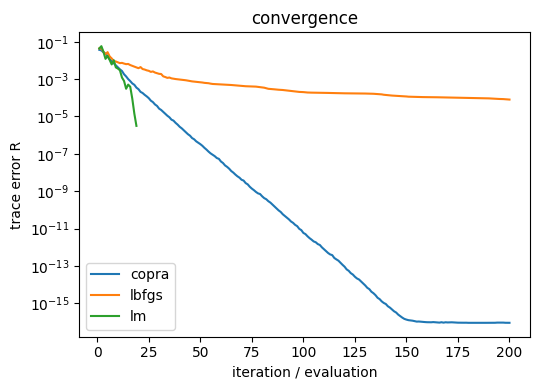

In [3]:
fig, ax = plt.subplots(figsize=(5.5, 4))
for algo, res in results.items():
    ax.semilogy(np.arange(1, len(res.errors) + 1), res.errors, label=algo)
ax.set_xlabel("iteration / evaluation")
ax.set_ylabel("trace error R")
ax.set_title("convergence")
ax.legend()
fig.tight_layout()

In [4]:
def lm_run(**tol):
    r = croak.retrieve(trace, g.omega, delays, "pg", algorithm="lm",
                      guess=guess, maxiters=400, **tol)
    return f"R = {r.error:.2e}  ({len(r.errors)} evaluations)"

print("vary reltol (ftol), abstol at its 1e-8 default:")
for reltol in (1e-4, 1e-8, 1e-12):
    print(f"   reltol={reltol:.0e}  {lm_run(reltol=reltol, abstol=1e-8)}")

print("vary abstol (xtol and gtol), reltol at its 1e-4 default:")
for abstol in (1e-8, 1e-12, 1e-15):
    print(f"   abstol={abstol:.0e}  {lm_run(reltol=1e-4, abstol=abstol)}")

vary reltol (ftol), abstol at its 1e-8 default:


retrieving:   0%|          | 0/400 [00:00<?, ?it/s]

retrieval complete — lm / pg
  final error R    : 0.0003%
  retrieved FWHM   : 4.76 fs
  transform limit  : 2.97 fs
  iterations       : 19
  time taken       : 1.39 s
   reltol=1e-04  R = 3.13e-06  (19 evaluations)


retrieving:   0%|          | 0/400 [00:00<?, ?it/s]

retrieval complete — lm / pg
  final error R    : 0.0003%
  retrieved FWHM   : 4.76 fs
  transform limit  : 2.97 fs
  iterations       : 19
  time taken       : 1.40 s
   reltol=1e-08  R = 3.13e-06  (19 evaluations)


...

retrieval complete — lm / pg
  final error R    : 0.0003%
  retrieved FWHM   : 4.76 fs
  transform limit  : 2.97 fs
  iterations       : 19
  time taken       : 1.43 s
   abstol=1e-08  R = 3.13e-06  (19 evaluations)


retrieving:   0%|          | 0/400 [00:00<?, ?it/s]

retrieval complete — lm / pg
  final error R    : 0.0000%
  retrieved FWHM   : 4.76 fs
  transform limit  : 3.00 fs
  iterations       : 36
  time taken       : 2.74 s
   abstol=1e-12  R = 2.26e-09  (36 evaluations)


retrieving:   0%|          | 0/400 [00:00<?, ?it/s]

retrieval complete — lm / pg
  final error R    : 0.0000%
  retrieved FWHM   : 4.76 fs
  transform limit  : 3.00 fs
  iterations       : 39
  time taken       : 3.08 s
   abstol=1e-15  R = 1.94e-12  (39 evaluations)


retrieving:   0%|          | 0/400 [00:00<?, ?it/s]

retrieval complete — lm / pg
  final error R    : 0.0000%
  retrieved FWHM   : 4.76 fs
  transform limit  : 3.00 fs
  iterations       : 42
  time taken       : 3.24 s


retrieving:   0%|          | 0/400 [00:00<?, ?it/s]

retrieval complete — lm / pg
  final error R    : 0.0000%
  retrieved FWHM   : 4.76 fs
  transform limit  : 3.00 fs
  iterations       : 35
  time taken       : 2.77 s


retrieving:   0%|          | 0/400 [00:00<?, ?it/s]

retrieval complete — lm / pg
  final error R    : 0.0003%
  retrieved FWHM   : 4.76 fs
  transform limit  : 2.97 fs
  iterations       : 19
  time taken       : 1.40 s


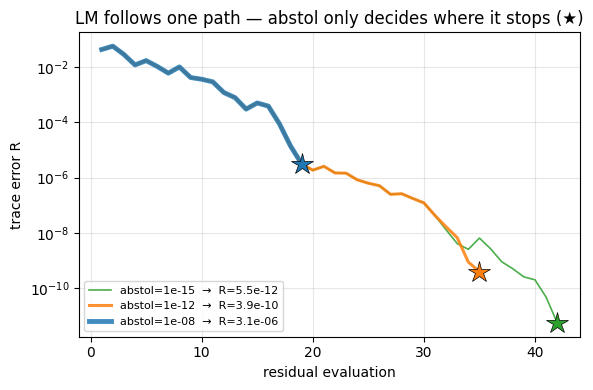

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
for abstol, lw, color in ((1e-15, 1.2, "C2"), (1e-12, 2.2, "C1"), (1e-8, 3.5, "C0")):
    r = croak.retrieve(trace, g.omega, delays, "pg", algorithm="lm", guess=guess,
                      maxiters=400, reltol=1e-4, abstol=abstol)
    n = np.arange(1, len(r.errors) + 1)
    ax.semilogy(n, r.errors, lw=lw, color=color, alpha=0.85,
                label=f"abstol={abstol:.0e}  →  R={r.error:.1e}")
    ax.plot(n[-1], r.errors[-1], "*", ms=16, color=color, mec="k", mew=0.5, zorder=5)
ax.set_xlabel("residual evaluation")
ax.set_ylabel("trace error R")
ax.set_title("LM follows one path — abstol only decides where it stops (★)")
ax.legend(fontsize=8, loc="lower left")
ax.grid(alpha=0.3)
fig.tight_layout()

In [6]:
from croak.metrics import trace_error

rng = np.random.default_rng(0)
direction = rng.standard_normal(ew.shape) + 1j * rng.standard_normal(ew.shape)
direction /= np.linalg.norm(direction)
scale = np.linalg.norm(ew)

print(f"{'eps':>8} {'R':>11} {'R/eps':>8} {'R^2/eps^2':>10}")
for eps in (1e-1, 1e-2, 1e-3, 1e-4):
    perturbed = ew + eps * scale * direction
    R = trace_error(trace, croak.maketrace(g.omega, delays, perturbed, "pg"))
    print(f"{eps:8.0e} {R:11.3e} {R / eps:8.4f} {R**2 / eps**2:10.6f}")

     eps           R    R/eps  R^2/eps^2
   1e-01   1.242e-03   0.0124   0.000154
   1e-02   1.205e-04   0.0120   0.000145
   1e-03   1.203e-05   0.0120   0.000145
   1e-04   1.203e-06   0.0120   0.000145


fitted slopes:  R -> 1.008   R^2 -> 2.015


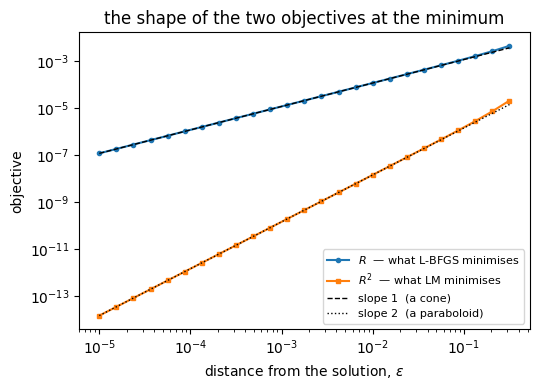

In [7]:
eps = np.logspace(-5, -0.5, 25)
R = np.array([trace_error(trace, croak.maketrace(g.omega, delays,
                                                 ew + e * scale * direction, "pg"))
              for e in eps])

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.loglog(eps, R, "o-", ms=3, label=r"$R$  — what L-BFGS minimises")
ax.loglog(eps, R**2, "s-", ms=3, label=r"$R^2$  — what LM minimises")
ax.loglog(eps, 0.012 * eps, "k--", lw=1, label="slope 1  (a cone)")
ax.loglog(eps, 1.45e-4 * eps**2, "k:", lw=1, label="slope 2  (a paraboloid)")
ax.set_xlabel(r"distance from the solution, $\epsilon$")
ax.set_ylabel("objective")
ax.set_title("the shape of the two objectives at the minimum")
ax.legend(fontsize=8)
fig.tight_layout()

print(f"fitted slopes:  R -> {np.polyfit(np.log(eps), np.log(R), 1)[0]:.3f}"
      f"   R^2 -> {np.polyfit(np.log(eps), np.log(R**2), 1)[0]:.3f}")

retrieving:   0%|          | 0/400 [00:00<?, ?it/s]

retrieval complete — lbfgs / pg
  final error R    : 0.0022%
  retrieved FWHM   : 4.70 fs
  transform limit  : 2.87 fs
  iterations       : 400
  time taken       : 2.70 s


retrieving:   0%|          | 0/400 [00:00<?, ?it/s]

retrieval complete — lbfgs-ad / pg
  final error R    : 0.0023%
  retrieved FWHM   : 4.71 fs
  transform limit  : 2.86 fs
  iterations       : 400
  time taken       : 0.42 s


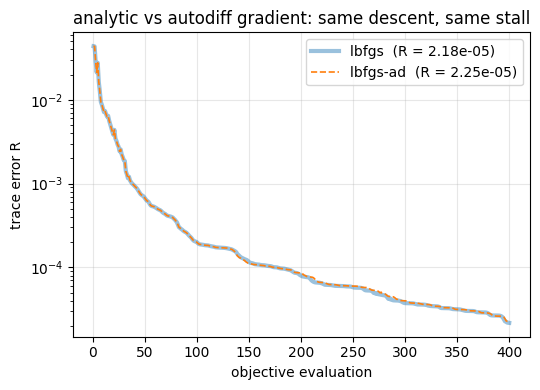

In [8]:
fig, ax = plt.subplots(figsize=(5.5, 4))
for algo, style in (("lbfgs", dict(lw=3.0, alpha=0.45)),
                    ("lbfgs-ad", dict(lw=1.2, ls="--"))):
    r = croak.retrieve(trace, g.omega, delays, "pg", algorithm=algo, guess=guess,
                      maxiters=400, reltol=1e-12, abstol=1e-15)
    ax.semilogy(np.arange(1, len(r.errors) + 1), r.errors,
                label=f"{algo}  (R = {r.error:.2e})", **style)
ax.set_xlabel("objective evaluation")
ax.set_ylabel("trace error R")
ax.set_title("analytic vs autodiff gradient: same descent, same stall")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

retrieving:   0%|          | 0/400 [00:00<?, ?it/s]

retrieval complete — copra / pg
  final error R    : 0.6321%
  retrieved FWHM   : 4.73 fs
  transform limit  : 0.34 fs
  iterations       : 400
  time taken       : 3.21 s


retrieving:   0%|          | 0/400 [00:00<?, ?it/s]

retrieval complete — lbfgs / pg
  final error R    : 0.6257%
  retrieved FWHM   : 4.71 fs
  transform limit  : 0.34 fs
  iterations       : 400
  time taken       : 2.71 s


retrieving:   0%|          | 0/400 [00:00<?, ?it/s]

retrieval complete — lm / pg
  final error R    : 0.6258%
  retrieved FWHM   : 4.11 fs
  transform limit  : 0.34 fs
  iterations       : 331
  time taken       : 25.88 s


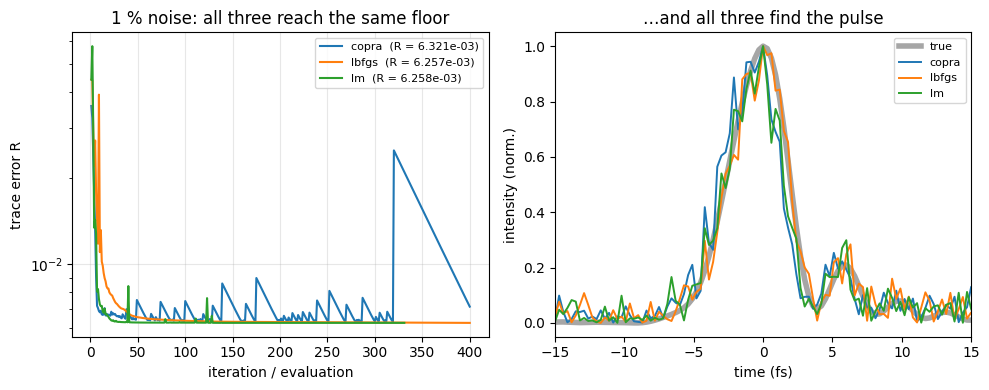

In [9]:
noise = np.random.default_rng(1).standard_normal(trace.shape)
noisy = np.clip(trace + 0.01 * trace.max() * noise, 0.0, None)

def centre(t, intensity):
    i = int(np.argmax(intensity))
    return (t - t[i]) * 1e15, intensity / intensity.max()

fig, (ax_conv, ax_pulse) = plt.subplots(1, 2, figsize=(10, 4))
ax_pulse.plot(*centre(g.t, np.abs(g.ifft(ew)) ** 2),
              lw=4, alpha=0.35, color="k", label="true")

for algo in ("copra", "lbfgs", "lm"):
    kw = dict(reltol=1e-12, abstol=1e-15) if algo != "copra" else {}
    r = croak.retrieve(noisy, g.omega, delays, "pg", algorithm=algo, guess=guess,
                      maxiters=400, rng=np.random.default_rng(0), **kw)
    ax_conv.semilogy(np.arange(1, len(r.errors) + 1), r.errors,
                     label=f"{algo}  (R = {r.error:.3e})")
    ax_pulse.plot(*centre(r.t, r.intensity_t), lw=1.4, label=algo)

ax_conv.set_xlabel("iteration / evaluation")
ax_conv.set_ylabel("trace error R")
ax_conv.set_title("1 % noise: all three reach the same floor")
ax_conv.legend(fontsize=8)
ax_conv.grid(alpha=0.3)
ax_pulse.set_xlim(-15, 15)
ax_pulse.set_xlabel("time (fs)")
ax_pulse.set_ylabel("intensity (norm.)")
ax_pulse.set_title("…and all three find the pulse")
ax_pulse.legend(fontsize=8)
fig.tight_layout()

In [10]:
hand = croak.retrieve(trace, g.omega, delays, "pg",
                     algorithm="lbfgs", guess=guess, maxiters=120)
auto = croak.retrieve(trace, g.omega, delays, "pg",
                     algorithm="lbfgs-ad", guess=guess, maxiters=120)
print(f"lbfgs     R = {hand.error:.3e}")
print(f"lbfgs-ad  R = {auto.error:.3e}")

retrieving:   0%|          | 0/120 [00:00<?, ?it/s]

retrieval complete — lbfgs / pg
  final error R    : 0.0173%
  retrieved FWHM   : 4.72 fs
  transform limit  : 2.86 fs
  iterations       : 120
  time taken       : 0.85 s


retrieving:   0%|          | 0/120 [00:00<?, ?it/s]

retrieval complete — lbfgs-ad / pg
  final error R    : 0.0173%
  retrieved FWHM   : 4.73 fs
  transform limit  : 2.86 fs
  iterations       : 120
  time taken       : 0.16 s
lbfgs     R = 1.731e-04
lbfgs-ad  R = 1.730e-04
